# __1. Summary & Hypothesis__

- __Act 1__: The Tactical Approach (Local Baselines).
- __Problem:__ Predicting "Foods in CA" (High volatility).
- **Hypothesis (testable):** On a **narrow, high‑volatility subset** (CA‑FOODS), a locally engineered LightGBM baseline will outperform N‑BEATSx due to limited data diversity and short history.

## Evaluation Contract (Act 1 — Local Dynamics)
- **Task:** 28‑day ahead daily forecasting on a **CA‑FOODS** subset (stress test: high volatility).
- **Split:** contiguous time split — **train** (history) → **valid** (next 28 days) → **test** (final 28 days).
- **Reporting metric:** **RMSE on the test window** for comparability with classical baselines.
- **Optimization vs reporting:** N‑BEATSx may be trained with **MQLoss (quantiles)**, but RMSE is computed on the **median** forecast. Quantiles are kept because they’re actionable for inventory decisions (service levels), not because RMSE “is wrong”.
- **Scope note:** conclusions in this notebook are **local-regime specific**; Act 2 tests whether cross‑learning changes the conclusion at full scale.

# __2. Data Loading & Filtering__

### CONFIGURATION & DATA LOADING

In [1]:
# One-time setup (no sys.path hacks): ensure editable install is available in this notebook kernel.
import sys
import subprocess
from pathlib import Path

def _find_project_root() -> Path:
    here = Path.cwd().resolve()
    if (here / "pyproject.toml").exists():
        return here
    if (here.parent / "pyproject.toml").exists():
        return here.parent
    return here

try:
    import walmart_demand_forecasting  # noqa: F401
except ModuleNotFoundError:
    project_root = _find_project_root()
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-e", str(project_root)])
    import walmart_demand_forecasting  # noqa: F401

In [2]:
import os
import torch
import pandas as pd
import numpy as np
import lightgbm as lgb
import gc

from walmart_demand_forecasting.datasets.m5 import load_ca_foods_lgbm, load_ca_foods_nf
from walmart_demand_forecasting.evaluation.split import (
    contiguous_day_split,
    split_date_for_last_horizon,
    train_test_split_by_date,
 )
from walmart_demand_forecasting.evaluation.metrics import rmse, merge_on_id_date
from walmart_demand_forecasting.models.lgbm.tuning import tune_lightgbm_optuna
from walmart_demand_forecasting.models.lgbm.training import train_lightgbm_with_best_params
from walmart_demand_forecasting.models.lgbm.inference import evaluate_lgbm_on_test_mask
from walmart_demand_forecasting.models.nbeatsx.pipeline import (
    cross_validate_neuralforecast,
    fit_neuralforecast,
    make_csv_logger,
    make_nbtx_loss_comparison_models,
    make_nbtx_mql_model,
    make_neuralforecast,
    merge_forecasts_with_actuals,
    predict_neuralforecast,
    reset_logs_dir,
    rmse_on_column,
 )
from walmart_demand_forecasting.visualization.nf_plotting import plot_nf_learning_curves
from walmart_demand_forecasting.features.m5_features import (
    add_cyclical_time_features,
    add_group_lags,
    add_group_rolling_means,
 )

- Import `read_and_squeeze` from `walmart_demand_forecasting.common.memory` to **downcast dtypes** and reduce RAM usage.


In [ ]:
# Utility imported above: `from walmart_demand_forecasting.common.memory import read_and_squeeze`
# (kept in `src/walmart_demand_forecasting/common/memory.py` so it can be reused).

### Loading and preprocessing

**Rationale for CA‑FOODS subset:**  
High volatility + dense promotions = a stress test for short‑term signal capture.  
This isolates local dynamics before scaling to the full hierarchy.

In [3]:
# ==========================================
# 1. CONFIGURATION & DATA LOADING
# ==========================================
TARGET = 'sales'
START_DAY = 1000  # Skip the first few years to save memory/time
HORIZON = 28      # Forecast horizon
print("Loading Data...")

# Load CA-FOODS panel (LGBM shape)
df_lgbm, cat_feats = load_ca_foods_lgbm(start_day=START_DAY)

display(df_lgbm)

Loading Data...
For sales_train_evaluation.csv, mem. usage decreased from 452.91 Mb to 96.13 Mb (78.8% reduction)
For calendar.csv, mem. usage decreased from  0.21 Mb to  0.12 Mb (41.9% reduction)
For sell_prices.csv, mem. usage decreased from 208.77 Mb to 130.48 Mb (37.5% reduction)


,id,item_id,dept_id,cat_id,store_id,state_id,d,sales,date,wday,month,year,event_name_1,event_type_1,event_name_2,event_type_2,wm_yr_wk,snap_CA,sell_price,d_int
5742252,FOODS_1_001_CA_1_evaluation,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,d_1000,1,2013-10-24,6,10,2013,NoEvent,NoEvent,NoEvent,NoEvent,11339,0,2.240234,1000
5742253,FOODS_1_002_CA_1_evaluation,FOODS_1_002,FOODS_1,FOODS,CA_1,CA,d_1000,0,2013-10-24,6,10,2013,NoEvent,NoEvent,NoEvent,NoEvent,11339,0,8.882812,1000
5742254,FOODS_1_003_CA_1_evaluation,FOODS_1_003,FOODS_1,FOODS,CA_1,CA,d_1000,0,2013-10-24,6,10,2013,NoEvent,NoEvent,NoEvent,NoEvent,11339,0,2.880859,1000
5742255,FOODS_1_004_CA_1_evaluation,FOODS_1_004,FOODS_1,FOODS,CA_1,CA,d_1000,4,2013-10-24,6,10,2013,NoEvent,NoEvent,NoEvent,NoEvent,11339,0,1.780273,1000
5742256,FOODS_1_005_CA_1_evaluation,FOODS_1_005,FOODS_1,FOODS,CA_1,CA,d_1000,1,2013-10-24,6,10,2013,NoEvent,NoEvent,NoEvent,NoEvent,11339,0,3.279297,1000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11156863,FOODS_3_823_CA_4_evaluation,FOODS_3_823,FOODS_3,FOODS,CA_4,CA,d_1941,0,2016-05-22,2,5,2016,NoEvent,NoEvent,NoEvent,NoEvent,11617,0,2.980469,1941
11156864,FOODS_3_824_CA_4_evaluation,FOODS_3_824,FOODS_3,FOODS,CA_4,CA,d_1941,0,2016-05-22,2,5,2016,NoEvent,NoEvent,NoEvent,NoEvent,11617,0,2.480469,1941
11156865,FOODS_3_825_CA_4_evaluation,FOODS_3_825,FOODS_3,FOODS,CA_4,CA,d_1941,0,2016-05-22,2,5,2016,NoEvent,NoEvent,NoEvent,NoEvent,11617,0,3.980469,1941
11156866,FOODS_3_826_CA_4_evaluation,FOODS_3_826,FOODS_3,FOODS,CA_4,CA,d_1941,4,2016-05-22,2,5,2016,NoEvent,NoEvent,NoEvent,NoEvent,11617,0,1.280273,1941


# __3. Feature Engineering (The "Tree" Way)__

### Create Lags (Lag-28 to Lag-49)

**Why explicit lags:**  
Tree models have no native memory. Lags and rolling means encode seasonality and autocorrelation explicitly.

In [4]:
# =========================
# 5. FEATURE ENGINEERING 
# =========================

print("Engineering Features...")

# 5.1 Cyclical time features (moved to src/utils/m5_features.py)
add_cyclical_time_features(df_lgbm, wday_col="wday", month_col="month")

# 5.2 Encode categoricals
# # Now 'None' / 'NoEvent' will be treated as just another category level.
# cat_feats = ['item_id', 'dept_id', 'store_id'] + event_cols
# for col in cat_feats:
#     df_lgbm[col] = df_lgbm[col].astype('category')

# 5.3 Lag + rolling mean features (moved to src/utils/m5_features.py)
print("Creating Lags...")
lags = [28, 35, 42, 49]
df_lgbm, lag_cols = add_group_lags(df_lgbm, group_col="id", value_col="sales", lags=lags, dtype="float32")

df_lgbm, rolling_cols = add_group_rolling_means(
    df_lgbm,
    group_col="id",
    value_col="sales",
    shift=28,
    windows=[7, 28,49],
    dtype="float32",
)

# 5.4 Drop rows with NaNs (warmup period only)
df_lgbm = df_lgbm.dropna(subset=lag_cols + rolling_cols)

# SORT (Preserve Time Structure)
df_lgbm = df_lgbm.sort_values(['id', 'd_int']).reset_index(drop=True)
display(df_lgbm)

Engineering Features...
Creating Lags...


,id,item_id,dept_id,cat_id,store_id,state_id,d,sales,date,wday,...,wday_cos,month_sin,month_cos,lag_28,lag_35,lag_42,lag_49,rolling_mean_7,rolling_mean_28,rolling_mean_49
0,FOODS_1_001_CA_1_evaluation,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,d_1076,0,2014-01-08,5,...,-0.222521,0.5,0.866025,0.0,0.0,0.0,0.0,0.000000,0.000000,0.061224
1,FOODS_1_001_CA_1_evaluation,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,d_1077,0,2014-01-09,6,...,0.623490,0.5,0.866025,0.0,0.0,0.0,0.0,0.000000,0.000000,0.040816
2,FOODS_1_001_CA_1_evaluation,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,d_1078,0,2014-01-10,7,...,1.000000,0.5,0.866025,0.0,0.0,0.0,0.0,0.000000,0.000000,0.040816
3,FOODS_1_001_CA_1_evaluation,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,d_1079,0,2014-01-11,1,...,0.623490,0.5,0.866025,0.0,0.0,0.0,0.0,0.000000,0.000000,0.020408
4,FOODS_1_001_CA_1_evaluation,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,d_1080,0,2014-01-12,2,...,-0.222521,0.5,0.866025,0.0,0.0,0.0,0.0,0.000000,0.000000,0.020408
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4977763,FOODS_3_827_CA_4_evaluation,FOODS_3_827,FOODS_3,FOODS,CA_4,CA,d_1937,3,2016-05-18,5,...,-0.222521,0.5,-0.866025,0.0,0.0,0.0,1.0,0.285714,1.571429,1.265306
4977764,FOODS_3_827_CA_4_evaluation,FOODS_3_827,FOODS_3,FOODS,CA_4,CA,d_1938,4,2016-05-19,6,...,0.623490,0.5,-0.866025,4.0,0.0,4.0,2.0,0.857143,1.571429,1.346939
4977765,FOODS_3_827_CA_4_evaluation,FOODS_3_827,FOODS_3,FOODS,CA_4,CA,d_1939,5,2016-05-20,7,...,1.000000,0.5,-0.866025,4.0,0.0,0.0,1.0,1.428571,1.678571,1.428571
4977766,FOODS_3_827_CA_4_evaluation,FOODS_3_827,FOODS_3,FOODS,CA_4,CA,d_1940,4,2016-05-21,1,...,0.623490,0.5,-0.866025,4.0,0.0,0.0,5.0,2.000000,1.785714,1.510204


# __4. Model A: The Baseline (LightGBM)__

### TRAIN / VALID / TEST SPLIT
**Split protocol:**  
Train → Valid → Test are **contiguous, time‑ordered** 28‑day windows.  
No leakage. test is the final 28 days.

In [5]:
# ======================
# 6. Train / Valid / Test SPLIT
# ======================
# Test set = Last 28 days available in data
split = contiguous_day_split(df_lgbm, horizon=HORIZON, d_int_col="d_int")

max_d = split.max_d
test_start = split.test_start
valid_start = split.valid_start

train_mask = split.train_mask
valid_mask = split.valid_mask
test_mask = split.test_mask

cv_mask = df_lgbm['d_int'] <= test_start

# Since I filtered for CA/FOODS, these are constant columns
# and will cause "Bad Pandas Dtypes" errors if left as strings.
# drop_cols = ['sales', 'd_int', 'id', 'd', 'date', 'wm_yr_wk', 'month', 'wday', 'snap_CA', 'cat_id', 'state_id']
drop_cols = ['sales', 'd', 'date', 'wm_yr_wk', 'month', 'wday', 'cat_id', 'state_id']

features = [c for c in df_lgbm.columns if c not in drop_cols]

# convert 'date' column to datetime
df_lgbm['date'] = pd.to_datetime(df_lgbm['date']) 

# sanity check
# print the min and max dates in df_lgbm_glob[train_mask] and df_lgbm_glob[valid_mask] and df_lgbm_glob[test_mask]
print(f"Train Set: {df_lgbm[train_mask]['date'].min().date()} to {df_lgbm[train_mask]['date'].max().date()}")
print(f"Valid Set: {df_lgbm[valid_mask]['date'].min().date()} to {df_lgbm[valid_mask]['date'].max().date()}")
print(f"Test Set: {df_lgbm[test_mask]['date'].min().date()} to {df_lgbm[test_mask]['date'].max().date()}")

# Create LGB Datasets
# free_raw_data=True helps free up pandas memory after loading into LGB
train_local_data = lgb.Dataset(
    df_lgbm[train_mask][features],
    label=df_lgbm[train_mask]['sales'],
    categorical_feature=cat_feats,
    free_raw_data=True
)
valid_local_data = lgb.Dataset(
    df_lgbm[valid_mask][features],
    label=df_lgbm[valid_mask]['sales'],
    reference=train_local_data,
    free_raw_data=True
)

Train Set: 2014-01-08 to 2016-03-27
Valid Set: 2016-03-28 to 2016-04-24
Test Set: 2016-04-25 to 2016-05-22


### Define the parameters and train the LightGBM model
- Using `optuna` to tune a minimal search space for laptop‑scale training.

In [6]:
import random

SEED = 42
np.random.seed(SEED)
random.seed(SEED)
# Note: `PYTHONHASHSEED` only fully applies if set before the kernel starts.
os.environ.setdefault("PYTHONHASHSEED", str(SEED))

print("Starting Hyperparameter Tuning with Optuna...")

# Create a smaller dataset for tuning to save time (e.g., 10% subsample)
# We use the full CV training period for tuning (train_mask), but subsample rows.
df_local_tune = df_lgbm[train_mask].sample(frac=0.1, random_state=SEED)

study, tune_data = tune_lightgbm_optuna(
    df_local_tune,
    features=features,
    y_col="sales",
    cat_feats=cat_feats,
    seed=SEED,
    n_trials=15,  # 15 trials is enough to show "seriousness"
    num_boost_round=500,
    nfold=3,
    study_name="M5_LGBM_Local",
    return_tune_data=True,
 )

print("Best Parameters found:")
print(study.best_params)

Starting Hyperparameter Tuning with Optuna...


[I 2026-01-26 14:44:37,152] A new study created in memory with name: M5_LGBM_Local
[I 2026-01-26 14:45:03,008] Trial 0 finished with value: 2.913327838760535 and parameters: {'tweedie_variance_power': 1.249816047538945, 'learning_rate': 0.09556428757689246}. Best is trial 0 with value: 2.913327838760535.
[I 2026-01-26 14:45:31,842] Trial 1 finished with value: 2.915175197970001 and parameters: {'tweedie_variance_power': 1.3927975767245622, 'learning_rate': 0.0638792635777333}. Best is trial 0 with value: 2.913327838760535.
[I 2026-01-26 14:46:03,398] Trial 2 finished with value: 2.9633897140546637 and parameters: {'tweedie_variance_power': 1.1624074561769746, 'learning_rate': 0.02403950683025824}. Best is trial 0 with value: 2.913327838760535.
[I 2026-01-26 14:46:29,303] Trial 3 finished with value: 2.9157215930942946 and parameters: {'tweedie_variance_power': 1.1232334448672798, 'learning_rate': 0.08795585311974417}. Best is trial 0 with value: 2.913327838760535.
[I 2026-01-26 14:46:5

Best Parameters found:
{'tweedie_variance_power': 1.3404460046972835, 'learning_rate': 0.0737265320016441}


In [7]:
# ==========================================
# 5. TRAINING (optimized)
# ==========================================
print("Training Local LightGBM with Optimized Parameters...")

model_local_lgbm, params = train_lightgbm_with_best_params(
    train_data=train_local_data,
    valid_data=valid_local_data,
    best_params=study.best_params,
    seed=SEED,
    num_boost_round=1500,
    early_stopping_rounds=100,
    log_evaluation=50,
 )

Training Local LightGBM with Optimized Parameters...
Training until validation scores don't improve for 100 rounds
[50]	training's rmse: 3.03996	valid_1's rmse: 2.68199
[100]	training's rmse: 2.89583	valid_1's rmse: 2.59992
[150]	training's rmse: 2.84727	valid_1's rmse: 2.58746
[200]	training's rmse: 2.80913	valid_1's rmse: 2.55819
[250]	training's rmse: 2.77126	valid_1's rmse: 2.54335
[300]	training's rmse: 2.73674	valid_1's rmse: 2.53857
[350]	training's rmse: 2.7075	valid_1's rmse: 2.54337
[400]	training's rmse: 2.66912	valid_1's rmse: 2.54495
Early stopping, best iteration is:
[349]	training's rmse: 2.70772	valid_1's rmse: 2.53441


Evaluating...

BASELINE RMSE: 2.6355
------------------------------
Feature Importance:


<Axes: title={'center': 'Feature importance'}, xlabel='Feature importance', ylabel='Features'>

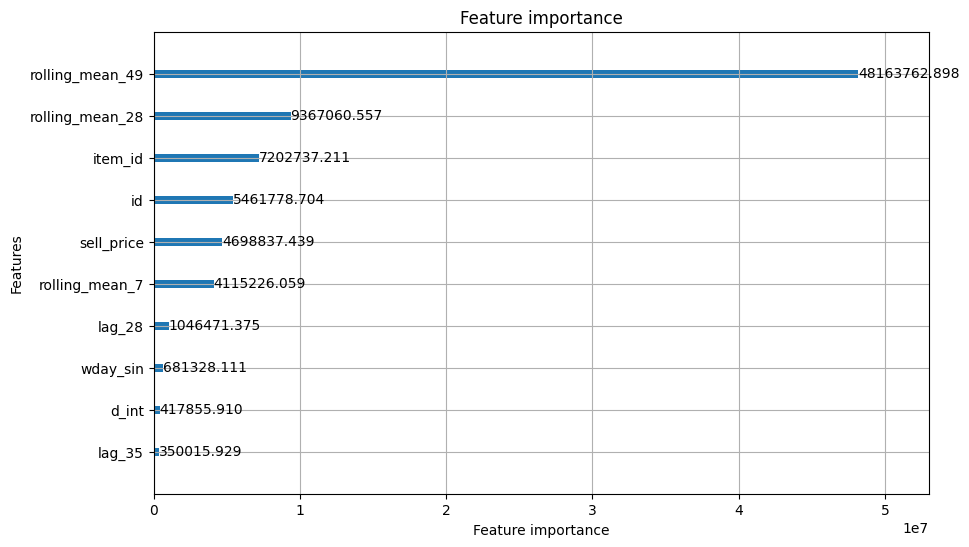

In [8]:
# ==========================================
# 8. EVALUATION
# ==========================================
print("Evaluating...")

df_lgbm_local_preds, lgbm_rmse = evaluate_lgbm_on_test_mask(
    model=model_local_lgbm,
    df=df_lgbm,
    test_mask=test_mask,
    features=features,
    id_col="id",
    date_col="date",
    y_col="sales",
    d_col="d",
 )

# Keep legacy variables used downstream
preds = df_lgbm_local_preds["lgbm_pred"].to_numpy()

print(f"\nBASELINE RMSE: {lgbm_rmse:.4f}")
print("-" * 30)
print("Feature Importance:")
lgb.plot_importance(model_local_lgbm, max_num_features=10, importance_type='gain', figsize=(10, 6))

# __5. Model B: The Pivot (Local N-BEATSx)__

In [9]:
import os
import random
import torch
import matplotlib.pyplot as plt

print(torch.backends.mps.is_available())  # Should be True if using a Mac with MPS support
print(torch.backends.mps.is_built())      # Should be True if PyTorch was built with MPS support

os.environ['PYTORCH_ENABLE_MPS_FALLBACK'] = '1'

True
True


### Data Loading and Filtring

In [10]:
# ==========================================
# 1. CONFIGURATION & DATA LOADING
# ==========================================
# Re-using your same filters to keep the comparison fair
START_DAY = 1000
HORIZON = 28
VAL_SIZE = 28

print("Loading Data...")

# Load CA-FOODS panel (NeuralForecast shape)
Y_df_nbtx = load_ca_foods_nf(start_day=START_DAY)

print(f"Data Prepared. NaNs in Price: {Y_df_nbtx['sell_price'].isna().sum()}")

Loading Data...
For sales_train_evaluation.csv, mem. usage decreased from 452.91 Mb to 96.13 Mb (78.8% reduction)
For calendar.csv, mem. usage decreased from  0.21 Mb to  0.12 Mb (41.9% reduction)
For sell_prices.csv, mem. usage decreased from 208.77 Mb to 130.48 Mb (37.5% reduction)
Data Prepared. NaNs in Price: 0


In [11]:
# ==========================================
# 4. TRAIN / TEST SPLIT (UPDATED)
# ==========================================
max_d = Y_df_nbtx['d_int'].max()
split_date = split_date_for_last_horizon(Y_df_nbtx, horizon=HORIZON, d_int_col="d_int", ds_col="ds")

# drop the 'd_int' column as it's no longer needed
Y_df_nbtx = Y_df_nbtx.drop(columns=['d_int'])

print(f"Splitting data at {split_date}")

train_df_nbtx, test_df_nbtx = train_test_split_by_date(Y_df_nbtx, split_date=split_date, ds_col="ds")

# FUTURE EXOGENOUS DATAFRAME
futr_exog_df = test_df_nbtx[['unique_id', 'ds', 'sell_price', 'is_available', 'snap_CA', 'is_event']]
print(f"Train Size: {len(train_df_nbtx)}")
print(f"Future Exog Size: {len(futr_exog_df)}")

# Sanity Check for FUTURE EXOGENOUS DF
missing_cols = set(['sell_price', 'is_available', 'snap_CA', 'is_event']) - set(futr_exog_df.columns)
if missing_cols:
    raise ValueError(f"Missing columns in future exogenous dataframe: {missing_cols}")

Splitting data at 2016-04-24 00:00:00
Train Size: 5253672
Future Exog Size: 160944


### Define N‑BEATSx using `NeuralForecast`
- Use `MQLoss` (stable on noisy retail demand); compare **median** to RMSE for fairness.

In [12]:
import matplotlib.pyplot as plt

print("Defining Models for NeuralForecast...")

# 1. DEFINE MODELS
common_params = dict(
    h=HORIZON,
    input_size=HORIZON * 13,
    scaler_type='robust',
    batch_size=512,  # this was 512 before I added more exogenous variables
    max_steps=3500,
    val_check_steps=12,
    early_stop_patience_steps=20,
    dropout_prob_theta=0.2,
    futr_exog_list=['sell_price', 'is_available', 'snap_CA', 'is_event'],
    exclude_insample_y=False,
    accelerator='mps',
    devices=1,
    enable_progress_bar=False,
 )

models = make_nbtx_loss_comparison_models(
    common_params,
    mql_learning_rate=1e-4,
    quantiles=(0.5, 0.8, 0.9),
    alias_rmse='NBEATSx_RMSE',
    alias_huber='NBEATSx_HUBER',
    alias_mql='NBEATSx_MQL',
 )

Defining Models for NeuralForecast...


Seed set to 1
Seed set to 1
Seed set to 1


In [13]:
# Runtime note: This CV step took 13m14.7s on my MacBook Pro M1 Pro

# 2. RUN CROSS-VALIDATION
print("Starting Simultaneous CV with Logging...")

cv_results = cross_validate_neuralforecast(
    models=models,
    df=train_df_nbtx,
    val_size=28,
    n_windows=3,
    step_size=28,
    freq='D',
 )

Starting Simultaneous CV with Logging...


GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name         | Type          | Params | Mode 
-------------------------------------------------------
0 | loss         | RMSE          | 0      | train
1 | padder_train | ConstantPad1d | 0      | train
2 | scaler       | TemporalNorm  | 0      | train
3 | blocks       | ModuleList    | 5.6 M  | train
-------------------------------------------------------
5.6 M     Trainable params
22.3 K    Non-trainable params
5.6 M     Total params
22.460    Total estimated model params size (MB)
40        Modules in train mode
0         Modules in eval mode
Trainer already configured with model summary callbacks: [<class 'pytorch_lightning.callbacks.model_summary.ModelSummary'>]. Skipping setting a default `ModelSummary` callback.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
GPU available: True (mps), used: True

In [14]:
display(cv_results)

,unique_id,ds,cutoff,NBEATSx_RMSE,NBEATSx_HUBER,NBEATSx_MQL-median,NBEATSx_MQL-hi-60.0,NBEATSx_MQL-hi-80.0,y
0,FOODS_1_001_CA_1_evaluation,2016-02-01,2016-01-31,0.673840,0.541407,0.344728,1.432283,2.106140,0
1,FOODS_1_001_CA_1_evaluation,2016-02-02,2016-01-31,0.633899,0.497022,0.293995,1.339277,1.964113,2
2,FOODS_1_001_CA_1_evaluation,2016-02-03,2016-01-31,0.612053,0.502697,0.304846,1.315591,1.916897,0
3,FOODS_1_001_CA_1_evaluation,2016-02-04,2016-01-31,0.666837,0.538213,0.368139,1.419294,2.074857,3
4,FOODS_1_001_CA_1_evaluation,2016-02-05,2016-01-31,0.691150,0.521064,0.417710,1.572543,2.180104,1
...,...,...,...,...,...,...,...,...,...
482827,FOODS_3_827_CA_4_evaluation,2016-04-20,2016-03-27,0.635414,0.216666,0.209285,1.399284,2.109123,0
482828,FOODS_3_827_CA_4_evaluation,2016-04-21,2016-03-27,0.674859,0.170594,0.200613,1.386209,2.152071,4
482829,FOODS_3_827_CA_4_evaluation,2016-04-22,2016-03-27,0.622242,0.194453,0.129880,1.266128,2.049034,4
482830,FOODS_3_827_CA_4_evaluation,2016-04-23,2016-03-27,0.560482,0.178541,0.080743,1.259410,2.047272,4


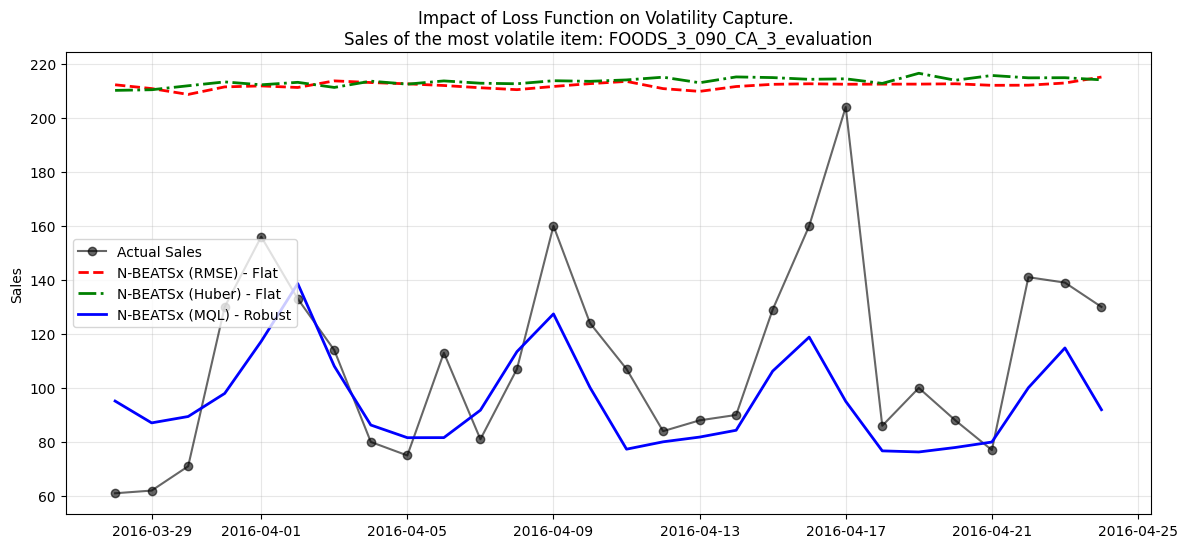

Cross Validation Verdict (Local Subset)
N-BEATSx (RMSE):   2.7628
N-BEATSx (Huber):  2.8015
N-BEATSx (MQ Loss):  2.6923
----------------------------------------


In [15]:
# ==========================================
# 5. THE "MONEY PLOT": FORECAST VISUALIZATION
# ==========================================
# 1. Select the last window (The Test Set)
last_cutoff = cv_results['cutoff'].max()
test_set = cv_results[cv_results['cutoff'] == last_cutoff]

# 2. Pick a volatile item (High variance in actuals)
item_var = test_set.groupby('unique_id')['y'].var()
volatile_item = item_var.idxmax()

subset = test_set[test_set['unique_id'] == volatile_item]

# 3. Plot
plt.figure(figsize=(14, 6))
plt.plot(subset['ds'], subset['y'], label='Actual Sales', color='black', marker='o', alpha=0.6)
plt.plot(subset['ds'], subset['NBEATSx_RMSE'], label='N-BEATSx (RMSE) - Flat', color='red', linestyle='--', linewidth=2)
plt.plot(subset['ds'], subset['NBEATSx_HUBER'], label='N-BEATSx (Huber) - Flat', color='green', linestyle='-.', linewidth=2)
plt.plot(subset['ds'], subset['NBEATSx_MQL-median'], label='N-BEATSx (MQL) - Robust', color='blue', linewidth=2)

plt.title(f"Impact of Loss Function on Volatility Capture. \nSales of the most volatile item: {volatile_item}")
plt.ylabel("Sales")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 4. Print the Scorecard for Act 1
rmse_rmse = rmse(cv_results['y'], cv_results['NBEATSx_RMSE'])
rmse_huber = rmse(cv_results['y'], cv_results['NBEATSx_HUBER'])
rmse_mql = rmse(cv_results['y'], cv_results['NBEATSx_MQL-median'])

print("="*40)
print("Cross Validation Verdict (Local Subset)")
print("="*40)
print(f"N-BEATSx (RMSE):   {rmse_rmse:.4f}")
print(f"N-BEATSx (Huber):  {rmse_huber:.4f}")
print(f"N-BEATSx (MQ Loss):  {rmse_mql:.4f}")
print("-" * 40)

### Physics vs. Business Interpretation:

- __The Trap of the Mean (RMSE & Huber):__ Retail data is right-skewed (sparse sales with occasional spikes). In such distributions, the __Mean > Median__. Models trained suing RMSE or Huber-loss predict the conditional mean. As seen in the plot, this results in a "flat" prediction that sits above typical sales.

- __Business Consequence (The "Worst of Both Worlds"):__

    - __Normal Days:__ We over-predict (Overstock/Waste).

    - __Peak Days:__ We under-predict (Stockouts/Lost Revenue).

- __The Solution (MQLoss):__ By minimizing Multi-Quantile Loss, we stop trying to predict a single "average" number.

    - **q=0.5 (Median):** Tracks the baseline demand accurately (avoiding overstock).
    
    - __q=0.9 (High Quantile):__ Captures the spikes (avoiding stockouts).

    - __Result:__ The oscillating blue line follows the structure of demand rather than just averaging it.

### Business interpretation: symmetric metrics vs asymmetric costs

- **RMSE (and Huber/RMSE training) is a symmetric objective.** It’s a good *reporting* metric for average accuracy, but it doesn’t encode the reality that over‑forecasting (waste/carrying cost) and under‑forecasting (stockouts/lost sales) can have different costs.
- **Inventory decisions are naturally quantile‑based.** Many planners want something like “forecast the 90th percentile” for a high service level, or the median for a neutral stance.
- **Why MQLoss helps here:** training on multiple quantiles teaches the model to represent the conditional distribution, not just a point estimate. In this notebook we **report RMSE on the median** for apples‑to‑apples comparability, while keeping upper quantiles for decision support.
- **How to read the plot:** the median tracks typical demand; higher quantiles react more to tail‑risk. This is a modeling choice tied to business policy (service level), not a claim that RMSE is “invalid.”

### Fit N‑BEATSx using MQ Loss on the training dataset and forecast the test horizon
**Why MQLoss here:**  
Quantile loss is more stable on noisy retail demand. The **median** is used for RMSE comparability.

In [17]:
print("Setting up Local N-BEATSx (MQLoss)...")

# 1. CLEANUP OLD LOGS (Crucial for reproducible plotting)
reset_logs_dir("logs/nbeats_mqloss_local/")

logger_mql_local = make_csv_logger("logs", name="nbeats_mqloss_local")

# 2. DEFINE MODEL
common_params = dict(
    h=HORIZON,
    input_size=HORIZON * 13,
    scaler_type='robust',
    batch_size=512,  # this was 512 before I added more exogenous variables
    max_steps=3500,
    val_check_steps=12,
    early_stop_patience_steps=20,
    dropout_prob_theta=0.2,
    futr_exog_list=['sell_price', 'is_available', 'snap_CA', 'is_event'],
    exclude_insample_y=False,
    accelerator='mps',
    devices=1,
    enable_progress_bar=False,
 )

model_mql = make_nbtx_mql_model(
    common_params,
    learning_rate=1e-4,
    quantiles=(0.5, 0.8, 0.9),
    alias='NBEATSx_MQL_Local',
    logger=logger_mql_local,
 )

Seed set to 1


Setting up Local N-BEATSx (MQLoss)...


In [18]:
nf_mqloss_FoodCA = make_neuralforecast(models=[model_mql], freq='D')

In [19]:
# ==========================================
# SINGLE SPLIT TRAINING
# ==========================================
# Runtime note: This step took ~10 minutes on my MacBook Pro M1 Pro

print("Starting Local Training...")

fit_neuralforecast(nf=nf_mqloss_FoodCA, df=train_df_nbtx, val_size=28)

print("Local Training Complete.")

Starting Local Training...


GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name         | Type          | Params | Mode 
-------------------------------------------------------
0 | loss         | MQLoss        | 3      | train
1 | padder_train | ConstantPad1d | 0      | train
2 | scaler       | TemporalNorm  | 0      | train
3 | blocks       | ModuleList    | 5.7 M  | train
-------------------------------------------------------
5.7 M     Trainable params
22.3 K    Non-trainable params
5.7 M     Total params
22.809    Total estimated model params size (MB)
40        Modules in train mode
0         Modules in eval mode


Local Training Complete.


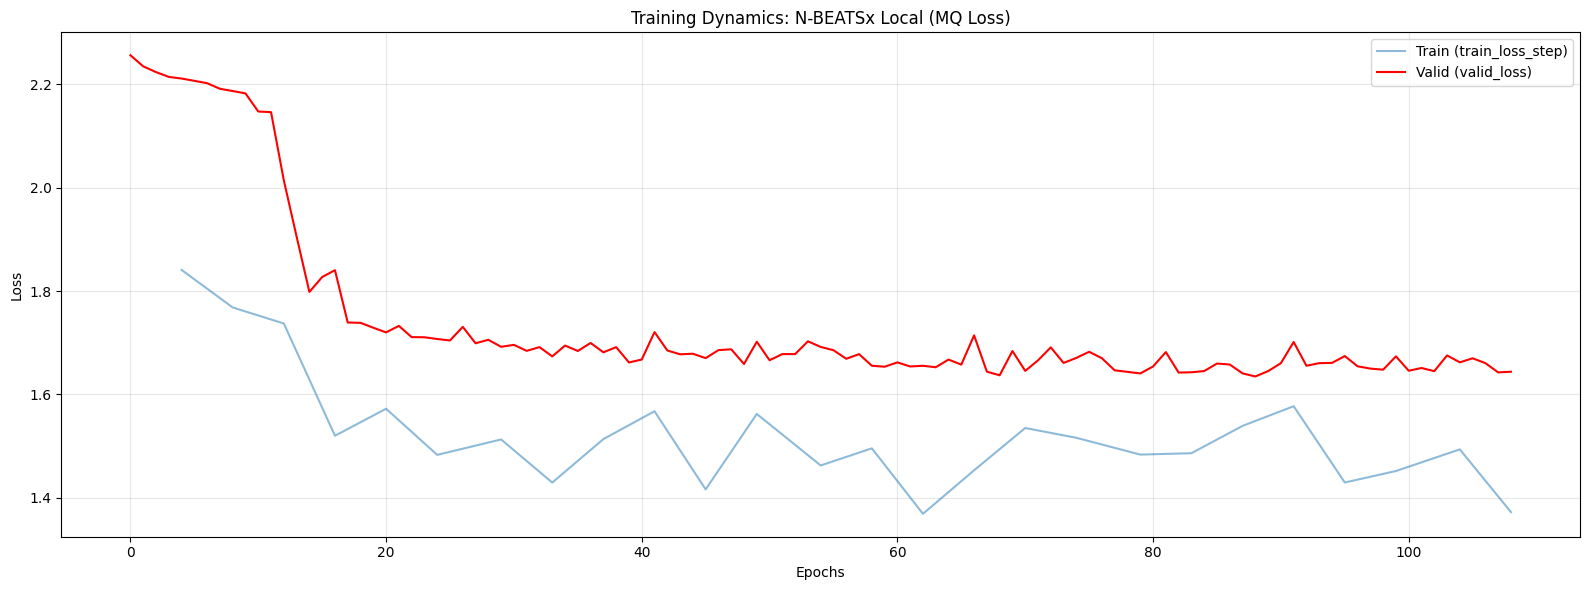

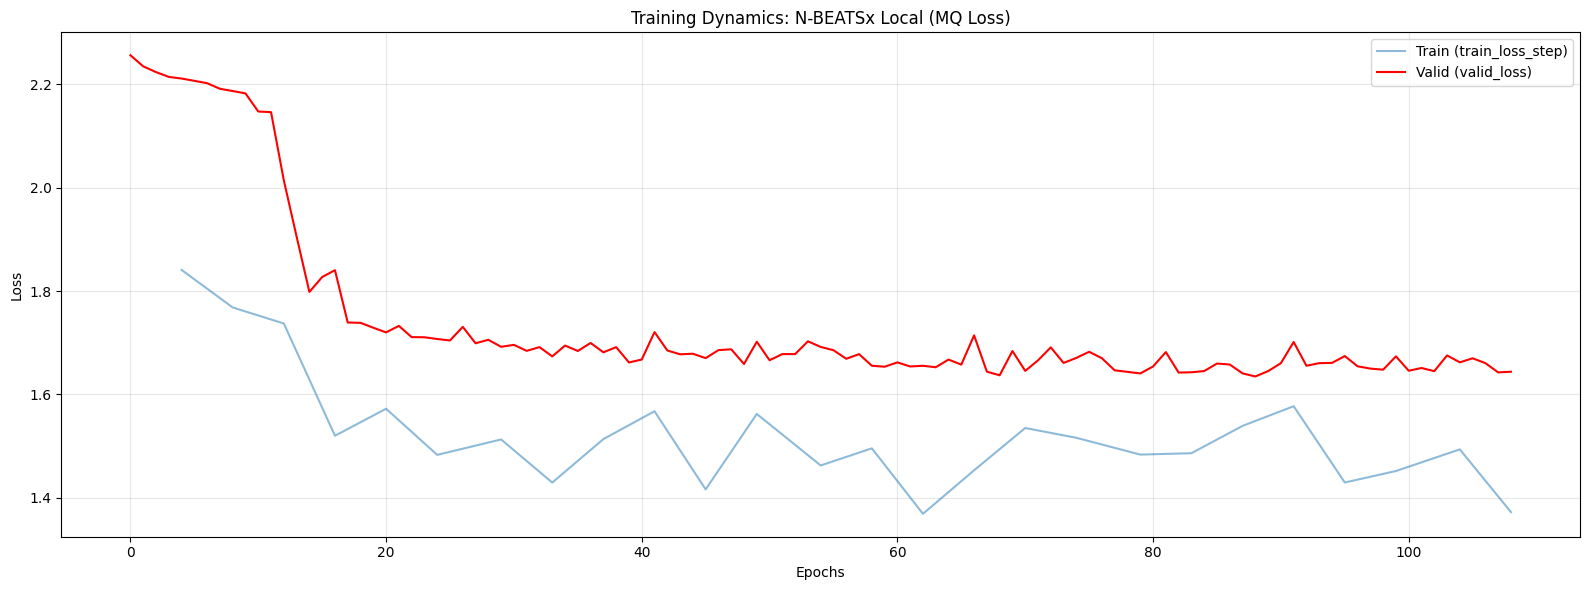

In [20]:
# ==========================================
# DIAGNOSTIC: TRAINING CURVES
# ==========================================
# Plots train/valid loss from Lightning CSVLogger metrics.csv
plot_nf_learning_curves(
    model_name="N-BEATSx Local (MQ Loss)",
    log_dir="logs/nbeats_mqloss_local",
    version="0",
 )

In [21]:
print("Predicting...")

# Making predictions using the trained NBEATSx model and future exogenous variables
forecasts_nf_mqloss_FoodCA = predict_neuralforecast(nf=nf_mqloss_FoodCA, futr_df=futr_exog_df)

# Merge predictions with actuals for evaluation
results_mqloss_FoodCA = merge_forecasts_with_actuals(
    forecasts=forecasts_nf_mqloss_FoodCA,
    actuals=test_df_nbtx[['unique_id', 'ds', 'y']],
    id_col='unique_id',
    ds_col='ds',
    y_col='y',
    how='left',
 )

print("Calculating RMSE...")
rmse_mqloss_FoodCA = rmse_on_column(
    df=results_mqloss_FoodCA,
    y_col='y',
    pred_col='NBEATSx_MQL_Local-median',
 )

print("="*40)
print(f"Local DATASET LightGBM RMSE: {lgbm_rmse:.4f}")
print(f"Local DATASET N-BEATSx RMSE: {rmse_mqloss_FoodCA:.4f}")
print("="*40)

Trainer already configured with model summary callbacks: [<class 'pytorch_lightning.callbacks.model_summary.ModelSummary'>]. Skipping setting a default `ModelSummary` callback.


Predicting...


GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Calculating RMSE...
Local DATASET LightGBM RMSE: 2.6355
Local DATASET N-BEATSx RMSE: 2.6286


In [23]:
# LightGBM predictions + actuals (standardized format from helper)
lgbm_output_local = df_lgbm_local_preds.copy()

# N-BEATSx predictions + actuals (already aligned on unique_id, ds)
pred_results = results_mqloss_FoodCA[["unique_id", "ds", "y", "NBEATSx_MQL_Local-median"]].rename(
    columns={"NBEATSx_MQL_Local-median": "nbtx_preds"}
 )
pred_results["ds"] = pd.to_datetime(pred_results["ds"])

# Merge models on (unique_id, ds)
preds_local_models = merge_on_id_date(
    pred_results,
    lgbm_output_local[["unique_id", "ds", "lgbm_pred"]],
    id_col="unique_id",
    ds_col="ds",
    how="left",
 )

# Convenience columns for existing plotting code
preds_local_models["date"] = preds_local_models["ds"]
preds_local_models["id"] = preds_local_models["unique_id"]

# Recalculate RMSE as a sanity check
print("Calculating RMSE...")
rmse_lgbm_FoodCA = rmse(preds_local_models["y"], preds_local_models["lgbm_pred"])
rmse_mqloss_FoodCA = rmse(preds_local_models["y"], preds_local_models["nbtx_preds"])
print("="*40)
print(f"Local DATASET LightGBM RMSE: {rmse_lgbm_FoodCA:.4f}")
print(f"Local DATASET N-BEATSx RMSE: {rmse_mqloss_FoodCA:.4f}")
print("="*40)

Calculating RMSE...
Local DATASET LightGBM RMSE: 2.6355
Local DATASET N-BEATSx RMSE: 2.6286


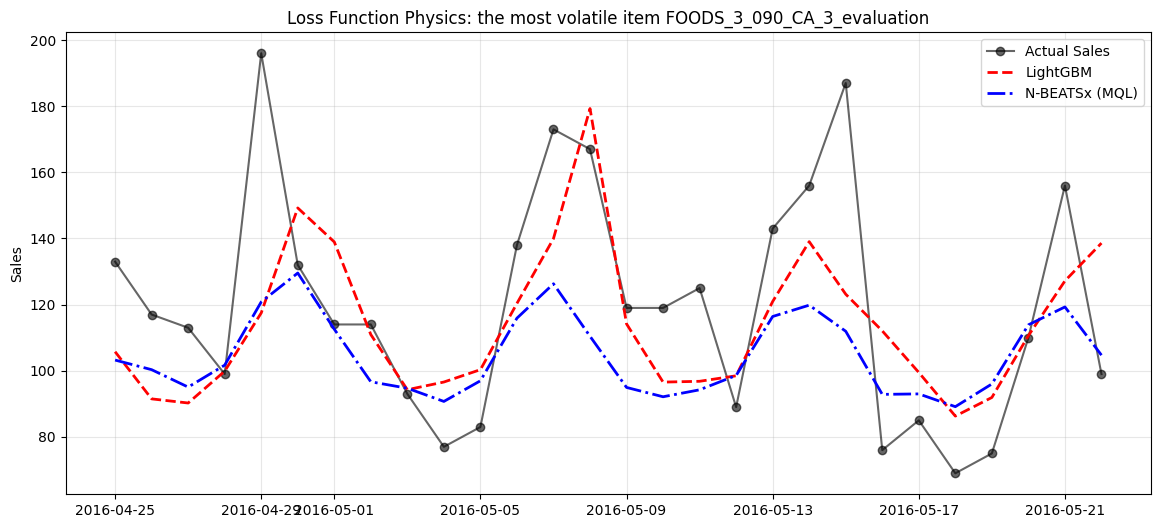

----------------------------------------


In [24]:
# ==========================================
# 5. THE "MONEY PLOT": FORECAST VISUALIZATION
# ==========================================

if "lgbm_preds" not in preds_local_models.columns and "lgbm_pred" in preds_local_models.columns:
    preds_local_models["lgbm_preds"] = preds_local_models["lgbm_pred"]

# 2. Pick a volatile item (High variance in actuals)
# We want to show a difficult case, not a flat one.
item_var = preds_local_models.groupby('id')['y'].var()
volatile_item = item_var.idxmax()

subset = preds_local_models[preds_local_models['id'] == volatile_item]

# 3. Plot
plt.figure(figsize=(14, 6))
plt.plot(subset['date'], subset['y'], label='Actual Sales', color='black', marker='o', alpha=0.6)
plt.plot(subset['date'], subset['lgbm_preds'], label='LightGBM', color='red', linestyle='--', linewidth=2)
plt.plot(subset['date'], subset['nbtx_preds'], label='N-BEATSx (MQL)', color='blue', linestyle='-.', linewidth=2)

plt.title(f"Loss Function Physics: the most volatile item {volatile_item}")
plt.ylabel("Sales")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()
print("-" * 40)

# **Conclusion (local):**  

- N-BEATSx outperforms LightGBM on the **local** CA‑FOODS subset (RMSE 2.6286 vs 2.6355).    
- Next step: scale the study to include all 30k series (see `02_global_scale.ipynb`).